# Labb 2

I den här labben undersöker jag hur en förtränad CNN-modell klassificerar bilder och vilka delar av bilderna modellen fokuserar på. Jag använder tre klasser: zebra, banana och sports car. För varje klass testar jag en positiv och en negativ bild. Bilderna genererades av chatGPT.

In [24]:
from pathlib import Path
import json
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.transforms.functional import to_pil_image
from torchcam.methods import SmoothGradCAMpp
from torchcam.utils import overlay_mask

images_dir = Path("images")
image_files = sorted(images_dir.glob("*.png"))

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
model.eval()
preprocess = weights.transforms()

with open("imagenet_class_index.json", "r") as f:
    imagenet_labels = json.load(f)

idx_to_label = {int(k): v[1] for k, v in imagenet_labels.items()}

target_classes = {
    "zebra": 340,
    "banana": 954,
    "sports car": 817,
}

print("Bilder i mappen:")
for file in image_files:
    print(file.name)


Bilder i mappen:
apple.png
Banan.png
bicycle.png
hourse.png
sportcar.png
zebra.png


## Modell

Jag valde `resnet18` med dess vikter.

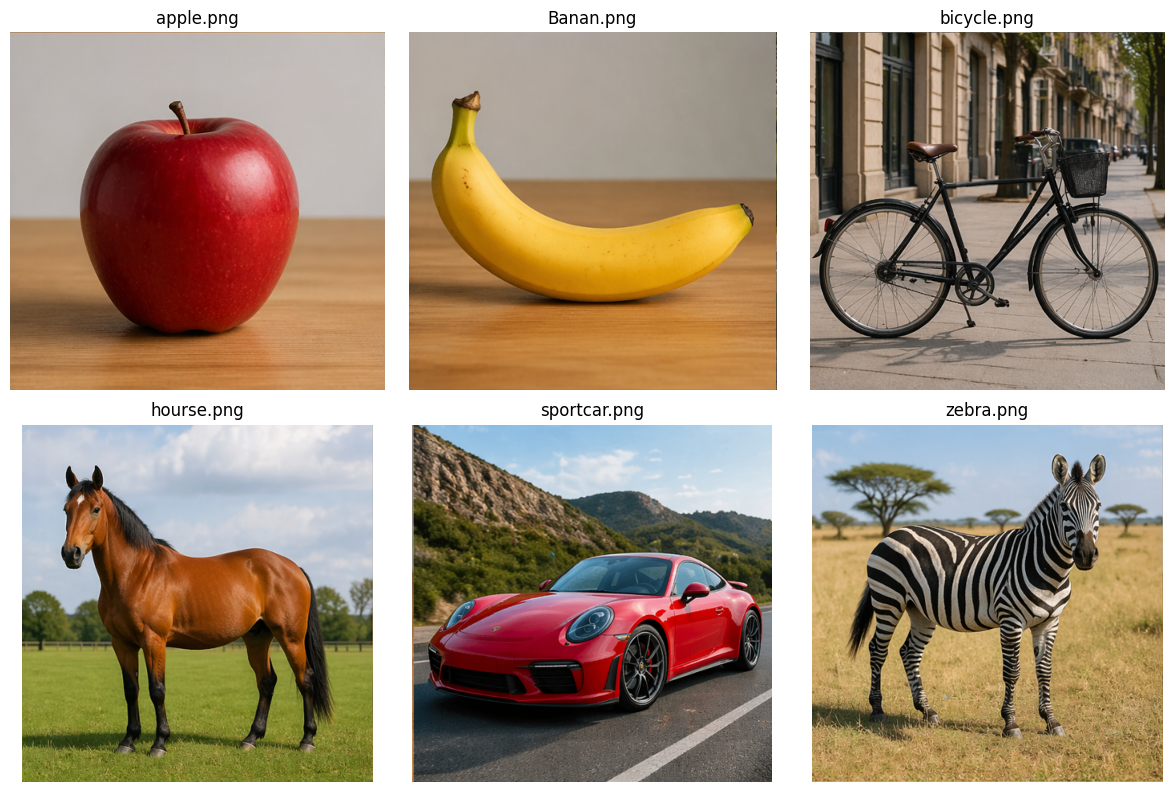

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for ax, file in zip(axes, image_files):
    image = Image.open(file).convert("RGB")
    ax.imshow(image)
    ax.set_title(file.name)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [26]:
def predict_image(image_name, topk=5):
    image = Image.open(images_dir / image_name).convert("RGB")
    input_tensor = preprocess(image).unsqueeze(0)

    logits = model(input_tensor)
    probs = torch.softmax(logits, dim=1)
    top_probs, top_idxs = probs.topk(topk, dim=1)

    print(f"\nBild: {image_name}")
    for rank, (idx, prob) in enumerate(zip(top_idxs[0], top_probs[0]), start=1):
        idx = idx.item()
        print(f"{rank}. {idx_to_label[idx]} ({prob.item():.4f})")

    return image, input_tensor, logits, probs


In [27]:
test_images = [
    "zebra.png",
    "hourse.png",
    "Banan.png",
    "apple.png",
    "sportcar.png",
    "bicycle.png",
]

for image_name in test_images:
    predict_image(image_name)



Bild: zebra.png
1. zebra (1.0000)
2. tiger_cat (0.0000)
3. tiger (0.0000)
4. cheetah (0.0000)
5. Egyptian_cat (0.0000)

Bild: hourse.png
1. sorrel (0.9914)
2. hartebeest (0.0031)
3. worm_fence (0.0014)
4. ox (0.0012)
5. horse_cart (0.0010)

Bild: Banan.png
1. banana (0.9947)
2. butternut_squash (0.0020)
3. spaghetti_squash (0.0007)
4. lemon (0.0007)
5. slug (0.0002)

Bild: apple.png
1. Granny_Smith (0.7254)
2. pomegranate (0.2206)
3. piggy_bank (0.0084)
4. orange (0.0060)
5. bell_pepper (0.0057)

Bild: sportcar.png
1. sports_car (0.9304)
2. convertible (0.0317)
3. car_wheel (0.0199)
4. racer (0.0099)
5. beach_wagon (0.0035)

Bild: bicycle.png
1. tricycle (0.3447)
2. moped (0.1665)
3. mountain_bike (0.1545)
4. bicycle-built-for-two (0.1512)
5. jinrikisha (0.0459)


Bilderna klassificeras bra av modellen.

In [28]:
cam_extractor = SmoothGradCAMpp(model)

def make_cam_result(image_name, class_idx):
    image = Image.open(images_dir / image_name).convert("RGB")
    input_tensor = preprocess(image).unsqueeze(0)
    out = model(input_tensor)

    activation_map = cam_extractor(class_idx, out)[0].squeeze(0).detach().cpu()
    activation_map -= activation_map.min()
    activation_map /= activation_map.max()

    heatmap = to_pil_image(activation_map, mode="F")
    result = overlay_mask(image, heatmap, alpha=0.5)
    return result


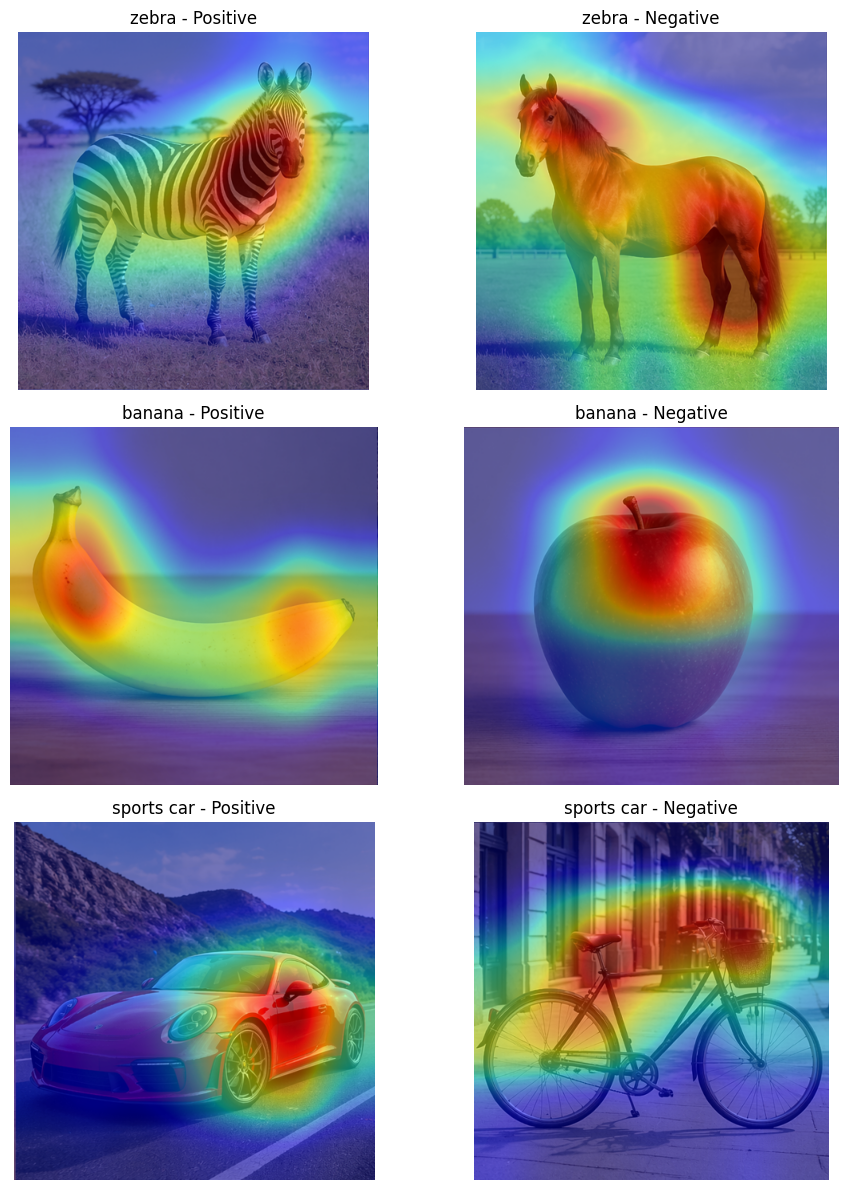

In [29]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

pairs = [
    ("zebra.png", 340, "zebra", "Positive"),
    ("hourse.png", 340, "zebra", "Negative"),
    ("Banan.png", 954, "banana", "Positive"),
    ("apple.png", 954, "banana", "Negative"),
    ("sportcar.png", 817, "sports car", "Positive"),
    ("bicycle.png", 817, "sports car", "Negative"),
]

for ax, (image_name, class_idx, class_name, label_type) in zip(axes.ravel(), pairs):
    result = make_cam_result(image_name, class_idx)
    ax.imshow(result)
    ax.set_title(f"{class_name} - {label_type}")
    ax.axis("off")

plt.tight_layout()
plt.show()



Bild: lennart.jpg
1. malamute (0.4355)
2. collie (0.1527)
3. Shetland_sheepdog (0.1259)
4. Siberian_husky (0.0767)
5. Eskimo_dog (0.0618)
6. keeshond (0.0491)
7. Border_collie (0.0231)
8. Pomeranian (0.0210)
9. Great_Pyrenees (0.0080)
10. Samoyed (0.0080)


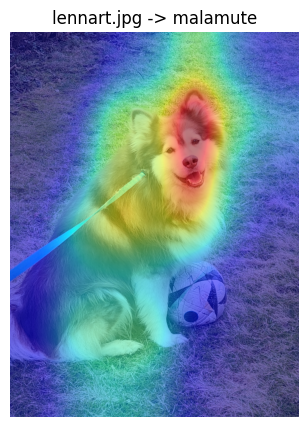

In [30]:
image, input_tensor, logits, probs = predict_image("lennart.jpg", topk=10)

pred_idx = probs.argmax(dim=1).item()
pred_label = idx_to_label[pred_idx]



result = make_cam_result("lennart.jpg", pred_idx)

plt.figure(figsize=(5, 5))
plt.imshow(result)
plt.title(f"lennart.jpg -> {pred_label}")
plt.axis("off")
plt.show()


## Analys av attribution maps

För zebra fokuserar modellen på ränder samt huvud och hals. I hästbilden finns aktivering över kroppen, vilket visar att modellen känner igen djurformen men saknar att den  saknar ränder.

För banan fokuserar modellen på den böjda formen och ändarna. I äpplet finns aktivering på toppen vilken är den delen som liknar en banan mest med dess stjälk, men formen stämmer inte med en banan.

För sportbil fokuserar modellen på front och kaross, jag har lite svårt att se varför den inte väljer att fokusera mer på fronten av bilen. Antar att däck och höjden till marken är någon avgörande faktor i denna klass. I cykeln finns stor spridd aktivering.

Jag ville testa med en egen bild på min hund Lennart, han är en finsk lapphund med klassades som en malamute med en stor osäkerhet. Då finsk lapphund inte finns ibland klasserna så är malmute väldigt bra gissat ändå då det är relativt nära besläktade.

Sammanfattningsvis använder modellen främst form och specifika kännetecken. Negativa exempel visar att den reagerar på likheter, men kräver rätt detaljer för korrekt klassificering.

In [31]:
image, input_tensor, logits, probs = predict_image("zebra.png", topk=10)

top_logits, top_idxs = logits[0].topk(10)

print("\nTop 10 logits for zebra.png:")
for rank, (idx, logit) in enumerate(zip(top_idxs, top_logits), start=1):
    idx = idx.item()
    print(f"{rank}. {idx_to_label[idx]:20s} logit={logit.item():8.3f}  prob={probs[0, idx].item():.6f}")



Bild: zebra.png
1. zebra (1.0000)
2. tiger_cat (0.0000)
3. tiger (0.0000)
4. cheetah (0.0000)
5. Egyptian_cat (0.0000)
6. leopard (0.0000)
7. prairie_chicken (0.0000)
8. jaguar (0.0000)
9. impala (0.0000)
10. gazelle (0.0000)

Top 10 logits for zebra.png:
1. zebra                logit=  22.757  prob=0.999974
2. tiger_cat            logit=  10.909  prob=0.000007
3. tiger                logit=  10.707  prob=0.000006
4. cheetah              logit=  10.305  prob=0.000004
5. Egyptian_cat         logit=   9.506  prob=0.000002
6. leopard              logit=   8.942  prob=0.000001
7. prairie_chicken      logit=   8.933  prob=0.000001
8. jaguar               logit=   8.747  prob=0.000001
9. impala               logit=   8.661  prob=0.000001
10. gazelle              logit=   8.444  prob=0.000001


## Logits

För zebra.png är modellen mycket säker på klassen zebra.

De närmaste klasserna är andra vilda djur som har någon slags markering i sin päls, alltså väljer den inte häst. Detta tyder på att modellen främst använder visuella mönster som ränder och struktur, snarare än form. Men den är också så säker på zebran så det är väldigt små marginaler till de näst kommande klasserna.

## Slutsats

Modellen fokuserar på relevanta delar av bilderna vid klassificering. Aktiverings mönstrerna är väldigt lika mellan zebra och häst, men sen så skiljer de sig väldigt mycket vilket förvånade mig lite. Logits visar att modellen är mycket säker på zebra, men jämför främst de liknande mönster i andra djurklasser före formen.
